
# Diabetes Visualization Exercises (Simple Version)

이 노트북은 다음 세 가지만 다룹니다.

1. **0 → NaN** 변환 후 **결측치 채우기(간단: 중앙값)**  
2. **각 컬럼 시각화** (숫자형: 히스토그램/막대)  
3. **`Outcome`과의 상관관계 히트맵**

> 데이터는 탭으로 구분된 TSV 형식(위에서 제공한 표)이라고 가정합니다.


In [1]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. 데이터 불러오기


- **파일 방식**: 같은 폴더에 `train.tsv`를 두고 실행


In [2]:
df =pd.read_csv('train.csv')
df

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,TRAIN_000,4,103,60,33,192,24.0,0.966,33,0
1,TRAIN_001,10,133,68,0,0,27.0,0.245,36,0
2,TRAIN_002,4,112,78,40,0,39.4,0.236,38,0
3,TRAIN_003,1,119,88,41,170,45.3,0.507,26,0
4,TRAIN_004,1,114,66,36,200,38.1,0.289,21,0
...,...,...,...,...,...,...,...,...,...,...
647,TRAIN_647,1,91,64,24,0,29.2,0.192,21,0
648,TRAIN_648,10,122,68,0,0,31.2,0.258,41,0
649,TRAIN_649,8,84,74,31,0,38.3,0.457,39,0
650,TRAIN_650,2,81,72,15,76,30.1,0.547,25,0



## 2. 0 → NaN 변환 (결측치로 간주할 컬럼만)

다음 컬럼들은 **0이 실제로 측정 불가/누락**을 의미하는 경우가 많습니다.  
- `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`

이 컬럼들만 0을 NaN으로 바꾸고, 나머지는 그대로 둡니다.


In [3]:
df.loc[df['Glucose']== 0 ,'Glucose'] = None
df.loc[df['BloodPressure']== 0 ,'BloodPressure'] = None
df.loc[df['SkinThickness']== 0 ,'SkinThickness'] = None
df.loc[df['Insulin']== 0 ,'Insulin'] = None
df.loc[df['BMI']== 0 ,'BMI'] = None
df

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,TRAIN_000,4,103.0,60.0,33.0,192.0,24.0,0.966,33,0
1,TRAIN_001,10,133.0,68.0,NaN,NaN,27.0,0.245,36,0
2,TRAIN_002,4,112.0,78.0,40.0,NaN,39.4,0.236,38,0
3,TRAIN_003,1,119.0,88.0,41.0,170.0,45.3,0.507,26,0
4,TRAIN_004,1,114.0,66.0,36.0,200.0,38.1,0.289,21,0
...,...,...,...,...,...,...,...,...,...,...
647,TRAIN_647,1,91.0,64.0,24.0,NaN,29.2,0.192,21,0
648,TRAIN_648,10,122.0,68.0,NaN,NaN,31.2,0.258,41,0
649,TRAIN_649,8,84.0,74.0,31.0,NaN,38.3,0.457,39,0
650,TRAIN_650,2,81.0,72.0,15.0,76.0,30.1,0.547,25,0


In [4]:
df.isnull().sum()

ID                            0
Pregnancies                   0
Glucose                       4
BloodPressure                30
SkinThickness               195
Insulin                     318
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## 3. 간단한 결측치 채우기 (중앙값)

각 컬럼의 **중앙값**으로 NaN을 채웁니다.


In [5]:
df['Glucose'].fillna(df['Glucose'].median(), inplace=True)

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_1185/3317550487.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Glucose'].fillna(df['Glucose'].median(), inplace=True)


In [6]:
df['BloodPressure'].fillna(df['BloodPressure'].median(),inplace=True)

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_1185/3771980892.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BloodPressure'].fillna(df['BloodPressure'].median(),inplace=True)


In [7]:
df['SkinThickness'].fillna(df['SkinThickness'].median(),inplace=True)

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_1185/1524214768.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SkinThickness'].fillna(df['SkinThickness'].median(),inplace=True)


In [8]:
df['Insulin'].fillna(df['Insulin'].median(),inplace=True)

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_1185/3032316621.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Insulin'].fillna(df['Insulin'].median(),inplace=True)


In [9]:
df['BMI'].fillna(df['BMI'].median(),inplace=True)

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_1185/4225218744.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BMI'].fillna(df['BMI'].median(),inplace=True)


In [10]:
df

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,TRAIN_000,4,103.0,60.0,33.0,192.0,24.0,0.966,33,0
1,TRAIN_001,10,133.0,68.0,29.0,125.0,27.0,0.245,36,0
2,TRAIN_002,4,112.0,78.0,40.0,125.0,39.4,0.236,38,0
3,TRAIN_003,1,119.0,88.0,41.0,170.0,45.3,0.507,26,0
4,TRAIN_004,1,114.0,66.0,36.0,200.0,38.1,0.289,21,0
...,...,...,...,...,...,...,...,...,...,...
647,TRAIN_647,1,91.0,64.0,24.0,125.0,29.2,0.192,21,0
648,TRAIN_648,10,122.0,68.0,29.0,125.0,31.2,0.258,41,0
649,TRAIN_649,8,84.0,74.0,31.0,125.0,38.3,0.457,39,0
650,TRAIN_650,2,81.0,72.0,15.0,76.0,30.1,0.547,25,0



## 4. 각 컬럼 시각화

- **숫자형**: 값의 종류가 적으면(예: Outcome=0/1) → 막대 그래프  
               값이 많으면 → 히스토그램  
- **문자형/범주형**: 빈도 막대 그래프


In [11]:
import seaborn as sns

In [12]:
# 'Pregnancies'
df['Pregnancies'].nunique()

16

In [13]:
Pg = df['Pregnancies'].value_counts()
PG = pd.DataFrame(Pg)
PG

,count
Pregnancies,
1,108
2,90
0,87
3,64
4,62
5,52
6,46
7,38
8,31


<Axes: xlabel='Pregnancies', ylabel='count'>

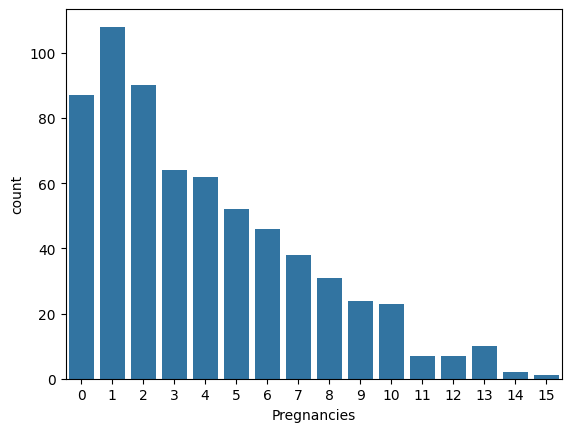

In [14]:
sns.barplot(PG , x= 'Pregnancies', y= 'count')

In [15]:
# 'Glucose'
df['Glucose'].nunique()

133

<Axes: xlabel='Glucose', ylabel='Count'>

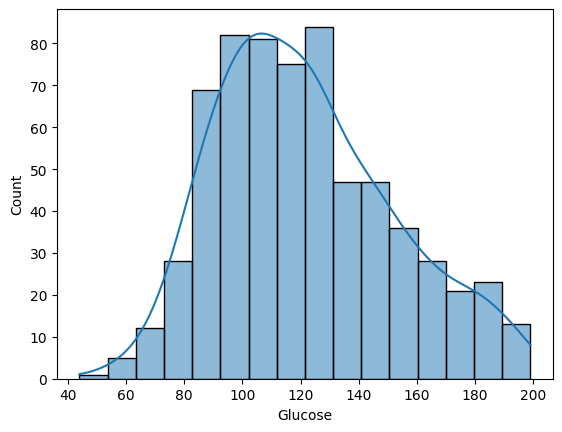

In [16]:
sns.histplot(df['Glucose'], kde=True)

In [17]:
# 'BloodPressure'
df['BloodPressure'].nunique()

45

<Axes: xlabel='BloodPressure', ylabel='Count'>

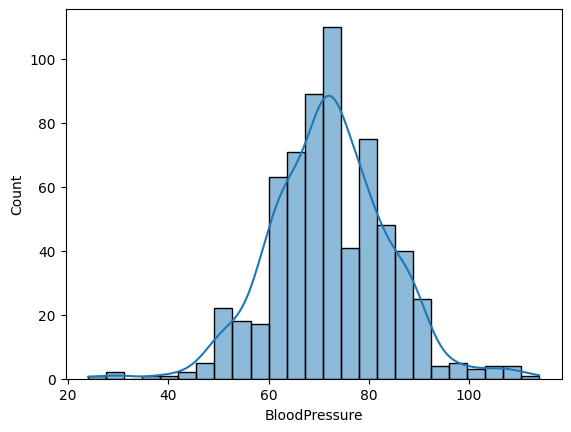

In [18]:
sns.histplot(df['BloodPressure'], kde=True)

In [19]:
# 'SkinThickness'
df['SkinThickness'].nunique()

48

<Axes: xlabel='SkinThickness', ylabel='Count'>

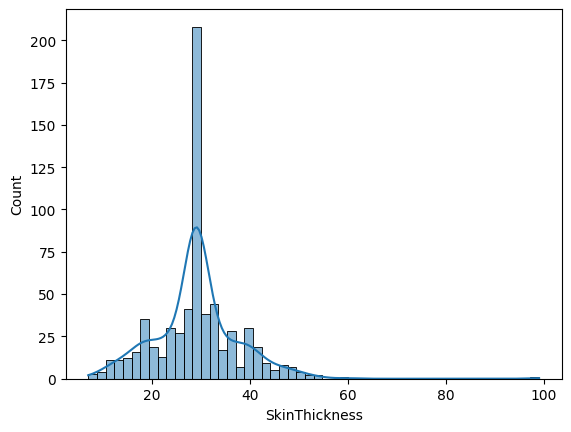

In [20]:
sns.histplot(df['SkinThickness'], kde=True)

In [21]:
# 'Insulin'
df['Insulin'].nunique()

172

<Axes: xlabel='Insulin', ylabel='Count'>

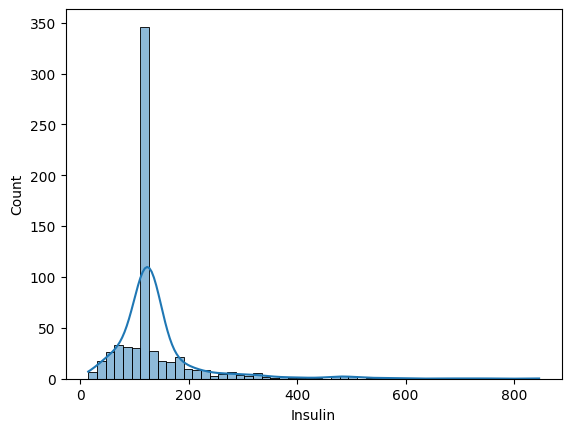

In [22]:
sns.histplot(df['Insulin'], kde=True)

In [23]:
# 'BMI'
df['BMI'].nunique()

231

<Axes: xlabel='BMI', ylabel='Count'>

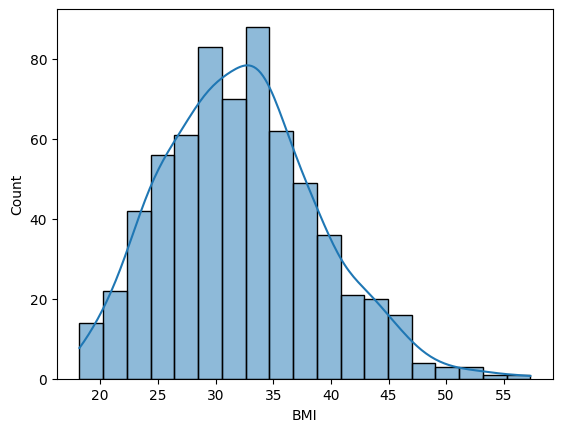

In [24]:
sns.histplot(df['BMI'], kde=True)

In [25]:
# 'DiabetesPedigreeFunction' 
df['DiabetesPedigreeFunction' ].nunique()

462

<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Count'>

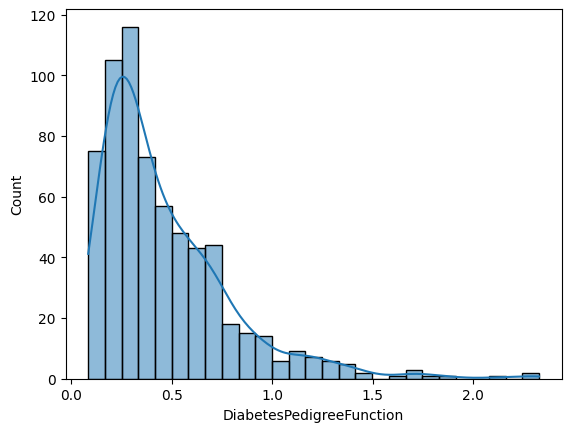

In [26]:
sns.histplot(df['DiabetesPedigreeFunction'], kde=True)

In [27]:
# 'Age' 
df['Age'].nunique()

52

<Axes: xlabel='Age', ylabel='Count'>

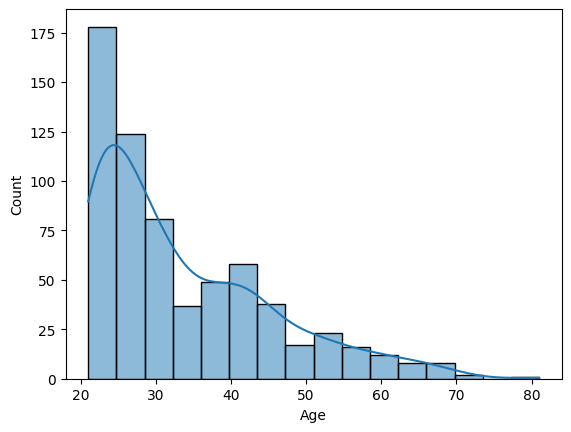

In [28]:
sns.histplot(df['Age'], kde=True)

In [29]:
# 'Outcome' : 막대 그래프
df['Outcome'].nunique()

2

In [30]:
outcome = df['Outcome'].value_counts()
Out = pd.DataFrame(outcome)
Out

,count
Outcome,
0,424
1,228


<Axes: xlabel='Outcome', ylabel='count'>

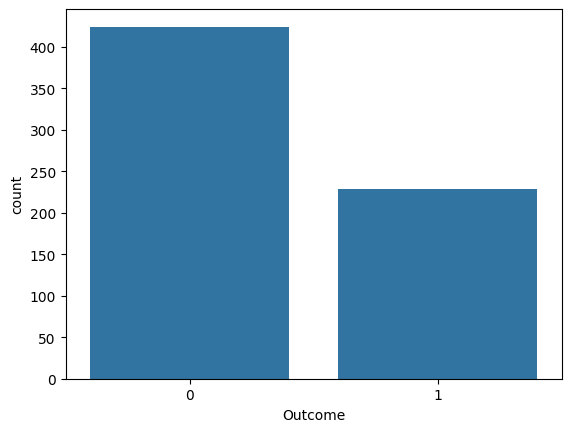

In [31]:
sns.barplot(Out , x='Outcome', y= 'count')


## 5. `Outcome`과의 상관관계 히트맵

- 수치형 컬럼만 상관계수를 계산합니다.
- `Outcome`과의 **상관 절댓값**이 큰 순서로 정렬해서 표시합니다.


In [50]:
df = df.select_dtypes('number')
df.corr() 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.103558,0.219418,0.095808,0.004230,0.046171,-0.028958,0.511983,0.211340
Glucose,0.103558,1.000000,0.220427,0.199073,0.427067,0.235341,0.124915,0.247014,0.489306
BloodPressure,0.219418,0.220427,1.000000,0.201295,0.039668,0.289410,-0.014194,0.318147,0.169275
SkinThickness,0.095808,0.199073,0.201295,1.000000,0.165079,0.508893,0.073266,0.141587,0.201677
Insulin,0.004230,0.427067,0.039668,0.165079,1.000000,0.194032,0.159074,0.083108,0.207654
BMI,0.046171,0.235341,0.289410,0.508893,0.194032,1.000000,0.111724,0.029922,0.306652
DiabetesPedigreeFunction,-0.028958,0.124915,-0.014194,0.073266,0.159074,0.111724,1.000000,0.035520,0.173584
Age,0.511983,0.247014,0.318147,0.141587,0.083108,0.029922,0.035520,1.000000,0.218183
Outcome,0.211340,0.489306,0.169275,0.201677,0.207654,0.306652,0.173584,0.218183,1.000000


In [51]:
df_Outcome = Df.loc['Outcome']
df_Outcome.sort_values()

BloodPressure               0.169275
DiabetesPedigreeFunction    0.173584
SkinThickness               0.201677
Insulin                     0.207654
Pregnancies                 0.211340
Age                         0.218183
BMI                         0.306652
Glucose                     0.489306
Outcome                     1.000000
Name: Outcome, dtype: float64


---

###  체크 포인트
- 0 → NaN 변환 대상 컬럼을 **명확히 지정**했나요?
- 중앙값으로 채우는 것이 합리적인가요? (다른 전략도 비교해 볼 수 있습니다)
- `Outcome`과 상관이 큰 컬럼은 무엇인가요? **해석**을 적어 보세요.


In [ ]:
print(
    '''
    Outcome과의 상관계수 중 1에 가장 근접치인 0.489306 수치가 나온 Glucose임으로
    데이터 안에 있는 요인중에서 당뇨에 가장 크게 영향을 주는것은 Glucose이다.
    
    ''')


In [ ]:
df[(df['Outcome'] = 1) | df['Glucoe']>]